In [1]:
import os
import re
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
fake=pd.read_csv("Fake.csv")
true=pd.read_csv("True.csv")

In [3]:
print(fake.columns)
print(true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [4]:
fake["label"] = 0
true["label"] = 1

In [5]:
fake["content"] = fake["title"].fillna("") + " " + fake["text"].fillna("")
true["content"] = true["title"].fillna("") + " " + true["text"].fillna("")

In [6]:
df = pd.concat([fake, true], ignore_index=True)
df = df[["content", "label"]]
print(df.head())
print(df.shape)

                                             content  label
0   Donald Trump Sends Out Embarrassing New Year’...      0
1   Drunk Bragging Trump Staffer Started Russian ...      0
2   Sheriff David Clarke Becomes An Internet Joke...      0
3   Trump Is So Obsessed He Even Has Obama’s Name...      0
4   Pope Francis Just Called Out Donald Trump Dur...      0
(44898, 2)


In [7]:
df = df.dropna(subset=["content"])
df = df[df["content"].str.strip() != ""]
print(df.shape)

(44898, 2)


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [9]:
df["content"] = df["content"].apply(clean_text)
print(df.iloc[10]["content"])

papa john s founder retires figures out racism is bad for business a centerpiece of donald trump s campaign and now his presidency has been his white supremacist ways that is why so many of the public feuds he gets into involve people of color one of his favorite targets is of course the players in the national football league who dare to exercise their first amendment rights by kneeling during the national anthem in protest of racist police brutality well there is one person who has figured out that racism is bad for business even if it did get the orange overlord elected the founder of the pizza chain papa john s this is a man who has never been on the right side of history on any number of issues and plus his pizza sucks but when he decided to complain about the players protesting his sales really dropped turns out racism doesn t pay and we all know that corporations are all about the bottom line therefore papa john schnatter will no longer be ceo of the hack pizza chain breaking pa

In [10]:
X = df["content"]
y = df["label"]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
text_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_df=0.7,
        min_df=2,
        ngram_range=(1, 2)
    )),
    ("clf", LinearSVC(C=1.0))
])

In [13]:
text_clf.fit(x_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:
predictions = text_clf.predict(x_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.9961024498886414

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



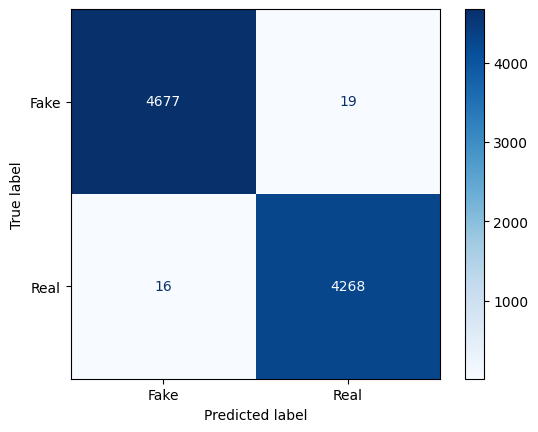

In [16]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap="Blues")
plt.show()

In [17]:
sample_news = [
    "The government has announced a new education policy for 2026.",
    "Aliens landed in Mumbai and took control of the parliament.",
    "Scientists discovered water on Mars in a new NASA study."
]

sample_news_clean = [clean_text(text) for text in sample_news]
preds = text_clf.predict(sample_news_clean)

for text, pred in zip(sample_news, preds):
    print("News:", text)
    print("Prediction:", "Real" if pred == 1 else "Fake")
    print("-" * 80)

News: The government has announced a new education policy for 2026.
Prediction: Fake
--------------------------------------------------------------------------------
News: Aliens landed in Mumbai and took control of the parliament.
Prediction: Fake
--------------------------------------------------------------------------------
News: Scientists discovered water on Mars in a new NASA study.
Prediction: Fake
--------------------------------------------------------------------------------


In [18]:
os.makedirs("MODEL", exist_ok=True)

with open("MODEL/model.pkl", "wb") as f:
    pickle.dump(text_clf, f)

print("Model saved successfully in MODEL/model.pkl")

Model saved successfully in MODEL/model.pkl


In [19]:
with open("MODEL/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

test_news = ["Breaking news: a major economic reform bill has been passed."]
test_news_clean = [clean_text(text) for text in test_news]

result = loaded_model.predict(test_news_clean)

print("Prediction:", "Real" if result[0] == 1 else "Fake")

Prediction: Fake


In [20]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
nlp = spacy.load("en_core_web_sm")

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

x = df["content"]
y = df["label"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

vectorizer = TfidfVectorizer()
x_train_tfidf = vectorizer.fit_transform(x_train)

clf = LinearSVC()      # ✅ create model

clf.fit(x_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.5042316258351893


In [27]:
import pickle

with open("MODEL/model.pkl", "wb") as f:
    pickle.dump(clf, f)

with open("MODEL/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

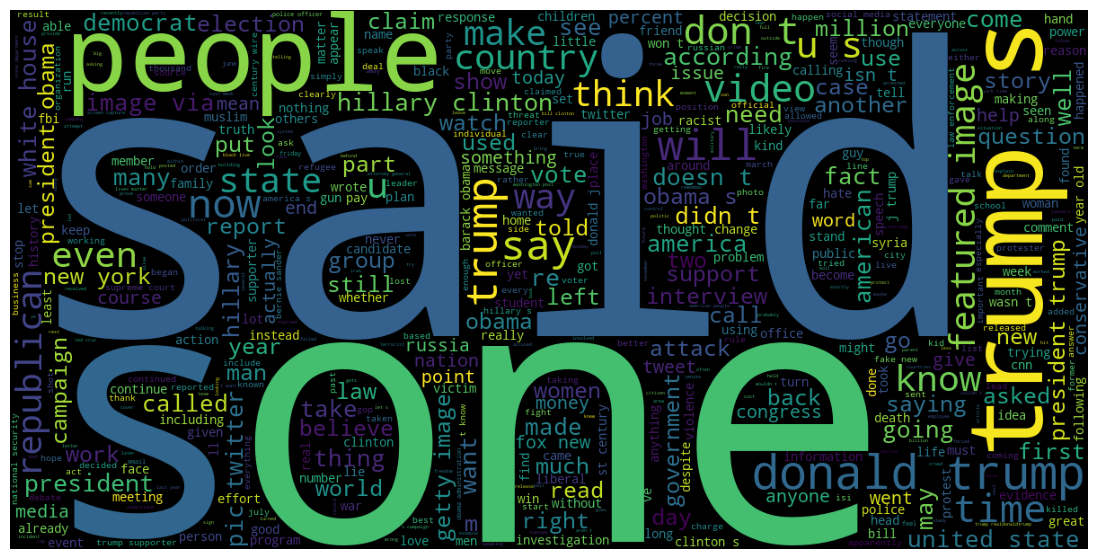

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = " ".join(df[df["label"] == 0]["content"])

wc = WordCloud(width=1200, height=600, background_color="black", max_words=500)
wc.generate(fake_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc)
plt.axis("off")
plt.show()

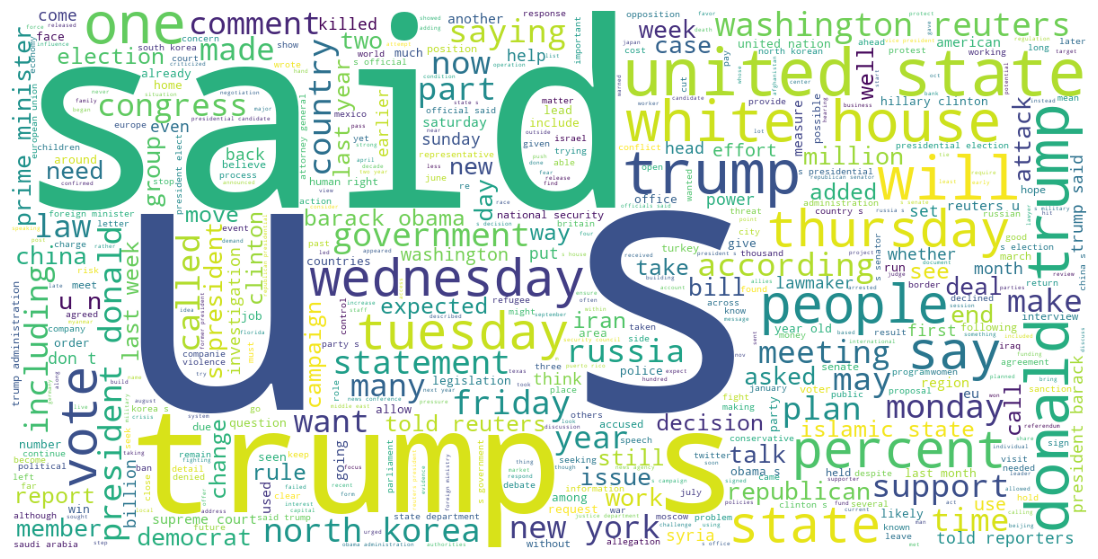

In [29]:
real_text = " ".join(df[df["label"] == 1]["content"])

wc = WordCloud(width=1200, height=600, background_color="white", max_words=500)
wc.generate(real_text)

plt.figure(figsize=(15, 7))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [30]:
sample_news = [
    "The president announced a new trade policy in Washington.",
    "NASA confirms new findings from Mars surface analysis.",
    "Aliens have officially taken over Earth governments.",
    "The central bank increased interest rates after inflation concerns."
]

sample_news_clean = [clean_text(text) for text in sample_news]
preds = text_clf.predict(sample_news_clean)

for text, pred in zip(sample_news, preds):
    print("News:", text)
    print("Prediction:", "Real" if pred == 1 else "Fake")
    print("-" * 80)

News: The president announced a new trade policy in Washington.
Prediction: Real
--------------------------------------------------------------------------------
News: NASA confirms new findings from Mars surface analysis.
Prediction: Fake
--------------------------------------------------------------------------------
News: Aliens have officially taken over Earth governments.
Prediction: Fake
--------------------------------------------------------------------------------
News: The central bank increased interest rates after inflation concerns.
Prediction: Real
--------------------------------------------------------------------------------
